# Wave-Front Tracking for ARZ  —  machine-precision ground truth

The ARZ analogue of `WFT-algorithm.ipynb` (scalar LWR). The homogeneous 
Aw–Rascle–Zhang system

$$\rho_t + (\rho v)_x = 0,\qquad (\rho w)_t + (\rho w\,v)_x = 0,\qquad v = w - p(\rho)$$

is solved by **wave-front tracking**: the solution is carried as a finite set 
of straight-line fronts moving at *exact* speeds — no spatial grid, so **zero 
numerical diffusion**. The only approximation is the rarefaction-fan resolution 
`rare_delta`; as it shrinks the result converges to the exact entropy solution, 
and for piecewise-constant data with no rarefactions it is exact to machine 
precision.

ARZ has a clean Riemann structure (a genuinely-nonlinear **1-wave** — shock or 
rarefaction — followed by a linearly-degenerate **2-contact**) with two exact 
Riemann invariants:

* `w` is constant across the 1-wave  →  `w_* = w_L`
* `v` is constant across the 2-contact →  contact speed `S_* = v_R`

so every elementary wave has a closed-form speed. Front collisions are resolved 
by re-solving the exact ARZ Riemann problem between the outer states.

This notebook imports the tested solver from `hyperbolic_pde.arz.wft_arz` (verified in `tests/test_wft_arz.py`: exact vs the 
analytic Riemann solver, mass-conserving, FV schemes converge to it).

In [1]:
import sys
sys.path.insert(0, '..')   # repo root

import numpy as np
import matplotlib.pyplot as plt

from hyperbolic_pde.arz import physics_arz as P
from hyperbolic_pde.arz.riemann_arz import solve_riemann_arz_xt
from hyperbolic_pde.arz.wft_arz import (
    ArzFrontTracking, solve_arz_wft_xt, solve_arz_wft_riemann_xt)
from hyperbolic_pde.arz import reference_arz as Ref

# Pressure closure: 'rho' (linear, the prho default) or 'rho+rho2' (AR).
P.set_pressure_form('rho')
print('pressure_form =', P.get_pressure_form())

pressure_form = rho


## 1. A single Riemann problem — fronts & space-time diagram

Build the front decomposition of one Riemann problem and draw its space-time 
(x–t) front diagram, exactly like the LWR notebook. Each line is one front; 
the 1-wave (shock = single line, rarefaction = a fan) is followed by the 
2-contact.

In [2]:
# Left / right primitive states (rho, v).
rhoL, vL = 0.75, 0.25     # rho decreases L->R across the 1-wave -> rarefaction
rhoR, vR = 0.25, 0.65
x0 = 0.5
T  = 0.6

# states are (rho, v) per segment; one interface here.
solver = ArzFrontTracking(boundaries=[x0], states=[(rhoL, vL), (rhoR, vR)],
                          rare_delta=0.03)
segments, history = solver.simulate(T)

print(f'{len(solver.fronts)} fronts at t=0 (incl. rarefaction fan slivers):')
for fr in ArzFrontTracking(boundaries=[x0],
                           states=[(rhoL, vL), (rhoR, vR)],
                           rare_delta=0.03).fronts:
    print(f'  {fr.kind:9s}  x={fr.x:.3f}  s={fr.s:+.4f}  L=(rho={fr.rho_l:.3f}, w={fr.w_l:.3f})  R=(rho={fr.rho_r:.3f}, w={fr.w_r:.3f})')

15 fronts at t=0 (incl. rarefaction fan slivers):
  rare1      x=0.500  s=-0.4714  L=(rho=0.750, w=1.000)  R=(rho=0.721, w=1.000)
  rare1      x=0.500  s=-0.4143  L=(rho=0.721, w=1.000)  R=(rho=0.693, w=1.000)
  rare1      x=0.500  s=-0.3571  L=(rho=0.693, w=1.000)  R=(rho=0.664, w=1.000)
  rare1      x=0.500  s=-0.3000  L=(rho=0.664, w=1.000)  R=(rho=0.636, w=1.000)
  rare1      x=0.500  s=-0.2429  L=(rho=0.636, w=1.000)  R=(rho=0.607, w=1.000)
  rare1      x=0.500  s=-0.1857  L=(rho=0.607, w=1.000)  R=(rho=0.579, w=1.000)
  rare1      x=0.500  s=-0.1286  L=(rho=0.579, w=1.000)  R=(rho=0.550, w=1.000)
  rare1      x=0.500  s=-0.0714  L=(rho=0.550, w=1.000)  R=(rho=0.521, w=1.000)
  rare1      x=0.500  s=-0.0143  L=(rho=0.521, w=1.000)  R=(rho=0.493, w=1.000)
  rare1      x=0.500  s=+0.0429  L=(rho=0.493, w=1.000)  R=(rho=0.464, w=1.000)
  rare1      x=0.500  s=+0.1000  L=(rho=0.464, w=1.000)  R=(rho=0.436, w=1.000)
  rare1      x=0.500  s=+0.1571  L=(rho=0.436, w=1.000)  R=(rho=0.407,

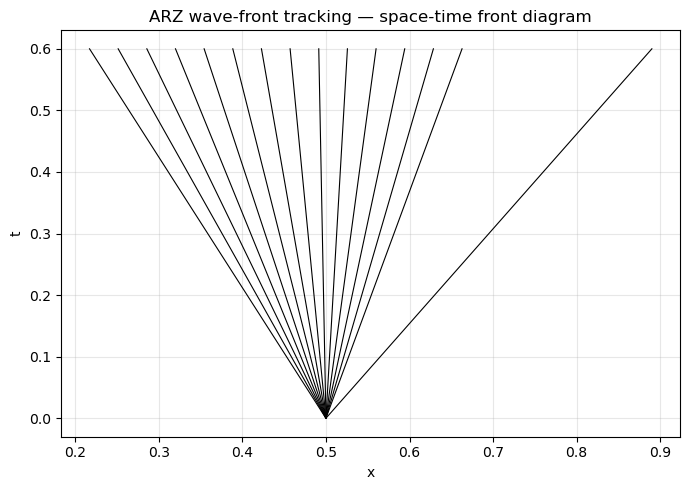

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for t0, xa, t1, xb in segments:
    ax.plot([xa, xb], [t0, t1], 'k-', lw=0.8)
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title('ARZ wave-front tracking — space-time front diagram')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Snapshot profiles vs the exact self-similar solution

Sample the WFT solution at several times and overlay the **exact** Riemann 
solution (`solve_riemann_arz_xt`). They should be indistinguishable — WFT is 
exact on the shock/contact and accurate to `rare_delta` inside the fan.

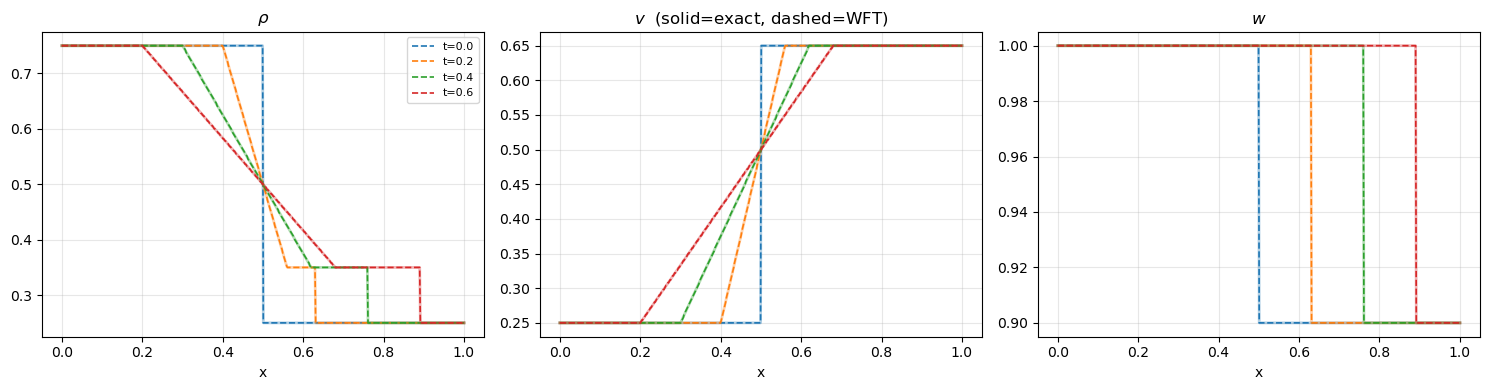

max |WFT - exact|   rho: 9.73e-04   v: 9.73e-04   w: 0.00e+00


In [4]:
nx = 600
x  = np.linspace(0.0, 1.0, nx)
t_snaps = np.array([0.0, 0.2, 0.4, 0.6])

# WFT on the (x, t) grid (re-solves per time internally).
rW, wW, vW = solve_arz_wft_riemann_xt(rhoL, vL, rhoR, vR, x, t_snaps,
                                      x0=x0, rare_delta=0.002)
# Exact self-similar reference.
wL = float(vL + P.pressure(np.array(rhoL))); wR = float(vR + P.pressure(np.array(rhoR)))
rE, wE, vE = solve_riemann_arz_xt(rhoL, wL, rhoR, wR, x, t_snaps, x0=x0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, (name, fW, fE) in enumerate(
        [(r'$\rho$', rW, rE), (r'$v$', vW, vE), (r'$w$', wW, wE)]):
    ax = axes[col]
    for k, tk in enumerate(t_snaps):
        ax.plot(x, fE[k], '-',  lw=2.0, alpha=0.35, color=f'C{k}')
        ax.plot(x, fW[k], '--', lw=1.2, color=f'C{k}', label=f't={tk:.1f}')
    ax.set_title(name); ax.set_xlabel('x'); ax.grid(alpha=0.3)
    if col == 0: ax.legend(fontsize=8)
axes[1].set_title(r'$v$  (solid=exact, dashed=WFT)')
plt.tight_layout(); plt.show()

# Quantify: max error split shock/contact (exact 0) vs fan (~rare_delta).
print('max |WFT - exact|   rho: %.2e   v: %.2e   w: %.2e'
      % (np.abs(rW-rE).max(), np.abs(vW-vE).max(), np.abs(wW-wE).max()))

## 3. WFT vs the finite-volume schemes (HLL / WENO5 / MUSCL)

The same Riemann problem solved by the finite-volume schemes on a grid. WFT 
sits exactly on the exact GT; the FV schemes smear the discontinuities — HLL 
most (note the spurious velocity spike at the contact), then WENO5 / MUSCL.

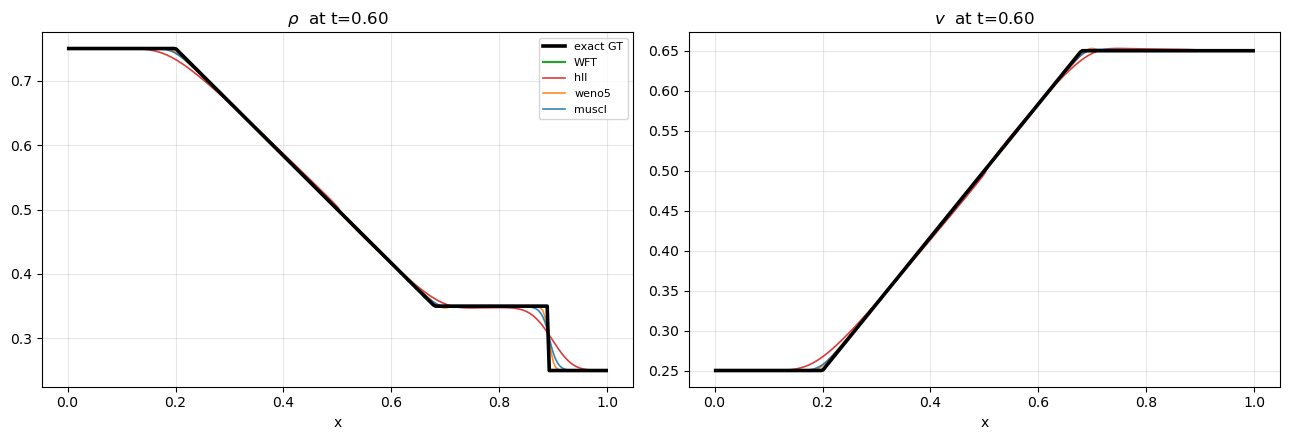

In [5]:
nx_g, nt_g, tmax = 256, 64, 0.6
dx = 1.0 / nx_g
xm = (np.arange(nx_g) + 0.5) * dx
tg = np.linspace(0.0, tmax, nt_g)
rho0 = np.where(xm <= x0, rhoL, rhoR).astype(float)
v0   = np.where(xm <= x0, vL,  vR ).astype(float)
w0   = v0 + P.pressure(rho0)

# Exact GT and WFT at final time.
rE2, wE2, vE2 = solve_riemann_arz_xt(rhoL, wL, rhoR, wR, xm, tg, x0=x0)
rW2, wW2, vW2 = solve_arz_wft_riemann_xt(rhoL, vL, rhoR, vR, xm, tg, x0=x0, rare_delta=0.002)

def fv(scheme):
    if scheme == 'muscl':
        r, w = Ref.solve_arz_muscl(rho0, w0, 0.0, 1.0, tmax, nt_g, tau=1e9, cfl=0.4, boundary='ghost')
    elif scheme == 'weno5':
        r, w = Ref.solve_arz_weno5(rho0, w0, 0.0, 1.0, tmax, nt_g, tau=1e9, cfl=0.2, boundary='ghost')
    else:
        _, _, r, w = Ref.solve_arz_reference(rho0, w0, 0.0, 1.0, tmax, nt_out=nt_g, tau=1e9,
                                             cfl=0.4, boundary='ghost', refine=1, flux_scheme=scheme)
    return r[-1], w[-1] - P.pressure(r[-1])

schemes = {'hll': 'tab:red', 'weno5': 'tab:orange', 'muscl': 'tab:blue'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, gt, wf) in zip(axes, [(r'$\rho$', rE2[-1], rW2[-1]),
                                      (r'$v$',    vE2[-1], vW2[-1])]):
    ax.plot(xm, gt, 'k-', lw=2.6, label='exact GT', zorder=5)
    ax.plot(xm, wf, '-', color='tab:green', lw=1.6, label='WFT')
    for s, c in schemes.items():
        rs, vs = fv(s)
        ax.plot(xm, rs if name==r'$\rho$' else vs, color=c, lw=1.2, alpha=0.9, label=s)
    ax.set_title(name + '  at t=%.2f' % tmax); ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. General multi-segment data (front collisions)

WFT handles arbitrary piecewise-constant ICs natively: each interface spawns 
its own waves, and when fronts collide the exact Riemann problem between the 
outer states is re-solved. There is **no closed-form GT** for multi-segment 
data, so here WFT *is* the ground truth (it's machine-precision for any 
piecewise-constant input). Below: a 4-segment IC, its front diagram, and its 
x–t heatmaps.

events: 7  fronts at end: 19


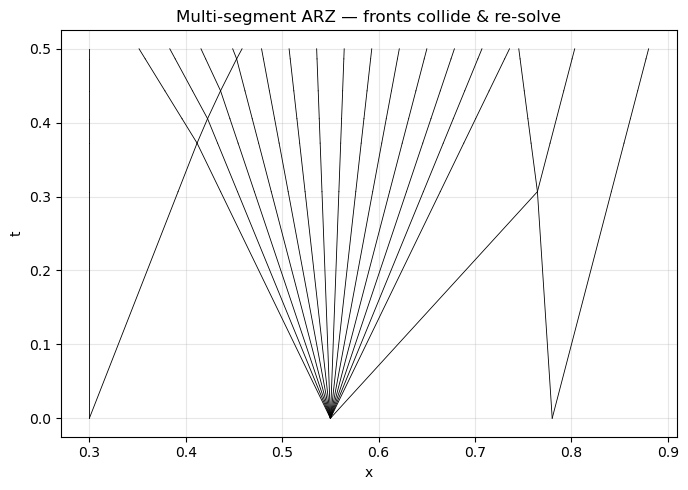

In [6]:
states = [(0.30, 0.80), (0.70, 0.30), (0.25, 0.70), (0.60, 0.20)]  # (rho, v)
bnd    = [0.30, 0.55, 0.78]
Tm     = 0.5

msolver = ArzFrontTracking(bnd, states, rare_delta=0.03)
segs, hist = msolver.simulate(Tm)
print('events:', len(hist), ' fronts at end:', len(msolver.fronts))

fig, ax = plt.subplots(figsize=(7, 5))
for t0, xa, t1, xb in segs:
    ax.plot([xa, xb], [t0, t1], 'k-', lw=0.6)
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title('Multi-segment ARZ — fronts collide & re-solve')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

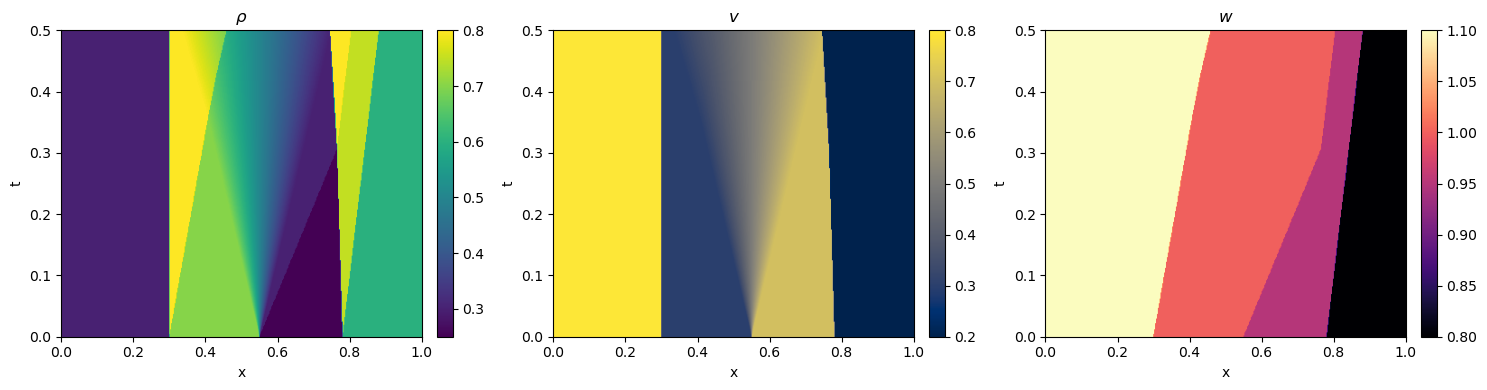

In [7]:
# x-t heatmaps of the WFT (=GT) solution for the multi-segment IC.
nx_h, nt_h = 400, 200
xh = (np.arange(nx_h) + 0.5) / nx_h
th = np.linspace(0.0, Tm, nt_h)
rH, wH, vH = solve_arz_wft_xt(states, bnd, xh, th, rare_delta=0.003)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, fld, cm) in zip(axes, [(r'$\rho$', rH, 'viridis'),
                                      (r'$v$', vH, 'cividis'),
                                      (r'$w$', wH, 'magma')]):
    im = ax.imshow(fld, origin='lower', aspect='auto',
                   extent=[0, 1, 0, Tm], cmap=cm)
    ax.set_title(name); ax.set_xlabel('x'); ax.set_ylabel('t')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 5. Convergence: rarefaction error → 0 with `rare_delta`

WFT's only error source is the rarefaction-fan discretization. On a problem 
with a 1-rarefaction the max error scales **linearly** in `rare_delta`; shocks 
and contacts stay exact regardless.

In [8]:
x = np.linspace(0.0, 1.0, 1000); t = np.array([0.4])
wL = float(vL + P.pressure(np.array(rhoL))); wR = float(vR + P.pressure(np.array(rhoR)))
rE, _, _ = solve_riemann_arz_xt(rhoL, wL, rhoR, wR, x, t, x0=x0)
print(f'{"rare_delta":>11s} {"max|err| rho":>14s}')
for rd in (0.04, 0.02, 0.01, 0.005, 0.0025):
    rW, _, _ = solve_arz_wft_riemann_xt(rhoL, vL, rhoR, vR, x, t, x0=x0, rare_delta=rd)
    print(f'{rd:11.4f} {np.abs(rW-rE).max():14.3e}')

 rare_delta   max|err| rho
     0.0400      1.960e-02
     0.0200      9.615e-03
     0.0100      4.620e-03
     0.0050      2.122e-03
     0.0025      8.734e-04
